# Lesson 10 — Probability and Statistics Intuition

**What this notebook does:** it counts probabilities straight from a small pile of support tickets, updates a belief when evidence arrives, watches wobbly small-sample frequencies settle toward the true probability, measures the mean and the spread of two agents' ratings, draws the shape of a whole distribution of resolution times, and finishes by making a toy classifier admit how sure it is.

Run the cells top to bottom, one at a time.

## 1. Probability by counting

A probability is a number between 0 and 1 that says what fraction of the time something happens. The cleanest first meeting with it is literal counting: here are 10 tickets with known categories. The chance that a randomly picked ticket is about shipping is simply the fraction of the pile that is shipping.

The next cell builds the pile as a NumPy array and counts each category's share. `categories == cat` gives an array of `True`/`False`, and taking its `.mean()` treats `True` as 1 and `False` as 0 — so the mean of the mask **is** the fraction, which **is** the probability. This one trick (mean of a boolean mask = fraction = probability) gets reused all lesson.

In [1]:
import numpy as np

categories = np.array([
    "shipping", "shipping", "shipping", "shipping", "shipping",
    "billing", "billing", "billing",
    "product", "product",
])

for cat in ["shipping", "billing", "product"]:
    p = np.mean(categories == cat)
    print(f"P({cat}) = {p}")

P(shipping) = 0.5
P(billing) = 0.3
P(product) = 0.2


## 2. Evidence changes belief

Before reading a ticket, the best guess for "is it billing?" is 0.3 — that is the base rate from the pile. But the moment we notice the ticket contains the word *refund*, the sensible belief changes. Among only the tickets that contain "refund", what fraction are billing?

That question — the probability of one thing **given** that another thing is known — is called a **conditional probability**, written `P(billing | refund)` and read "the probability of billing *given* refund". It is the entire logic of classification in miniature: a classifier's whole job is to answer `P(category | the words in the ticket)`.

The next cell marks which of the 10 tickets contain "refund" (one shipping ticket asking to refund a shipping fee, and two billing tickets), then counts within just that group. Notice the mechanism: filter with a boolean mask (Lesson 05's trick), then take a fraction inside the filtered pile.

In [2]:
contains_refund = np.array([
    False, False, False, False, True,
    True, True, False,
    False, False,
])

p_billing = np.mean(categories == "billing")
refund_tickets = categories[contains_refund]
p_billing_given_refund = np.mean(refund_tickets == "billing")

print(f"P(billing) = {p_billing}")
print(f"tickets containing 'refund': {len(refund_tickets)}")
print(f"P(billing | contains 'refund') = {p_billing_given_refund:.3f}")

P(billing) = 0.3
tickets containing 'refund': 3
P(billing | contains 'refund') = 0.667


## 3. The long run: small samples wobble

A probability describes the **long run**, not any single handful. If shipping tickets truly arrive 50% of the time, a day with 10 tickets can easily bring 3 or 7 of them — no surprise, nothing broken. Only as the count grows do the observed fractions settle down onto the true probabilities. (The formal name for this settling is the **law of large numbers**.)

The next cell simulates ticket arrivals. `np.random.default_rng(42)` creates a random-number generator with a fixed starting point called a **seed**: the draws are still perfectly fair, but rerunning the notebook gives the *same* draws every time, so results are reproducible. Then it draws 10, 100, and 100,000 tickets from the true probabilities `[0.5, 0.3, 0.2]` and prints the observed fractions at each size. Watch the wobble shrink as `n` grows.

In [14]:
rng = np.random.default_rng(42)
names = ["shipping", "billing", "product"]
true_p = [0.5, 0.3, 0.2]

def explain_draw(n):
    print(f"=== drawing n = {n} simulated tickets ===")

    print(f"step 1: roll a weighted 3-sided die {n} times, using true_p = {true_p}")
    draws = rng.choice(names, size=n, p=true_p)
    preview = draws[:10].tolist()
    print(f"    first {len(preview)} draws (out of {n}): {preview}")

    print(f"step 2: count how many draws landed on each category")
    counts = {name: int(np.sum(draws == name)) for name in names}
    print(f"    counts = {counts}")

    print(f"step 3: turn each count into an observed fraction (count / n)")
    observed = {name: np.mean(draws == name) for name in names}
    for name in names:
        print(f"    P({name}) = {counts[name]} / {n} = {observed[name]:.3f}")

    print(f"step 4: compare the observed fraction to the true probability we drew from")
    for name, p in zip(names, true_p):
        gap = observed[name] - p
        print(f"    true P({name}) = {p}   observed = {observed[name]:.3f}   gap = {gap:+.3f}")
    print()

for n in [10, 100, 100_000]:
    explain_draw(n)

=== drawing n = 10 simulated tickets ===
step 1: roll a weighted 3-sided die 10 times, using true_p = [0.5, 0.3, 0.2]
    first 10 draws (out of 10): ['billing', 'shipping', 'product', 'billing', 'shipping', 'product', 'billing', 'billing', 'shipping', 'shipping']
step 2: count how many draws landed on each category
    counts = {'shipping': 4, 'billing': 4, 'product': 2}
step 3: turn each count into an observed fraction (count / n)
    P(shipping) = 4 / 10 = 0.400
    P(billing) = 4 / 10 = 0.400
    P(product) = 2 / 10 = 0.200
step 4: compare the observed fraction to the true probability we drew from
    true P(shipping) = 0.5   observed = 0.400   gap = -0.100
    true P(billing) = 0.3   observed = 0.400   gap = +0.100
    true P(product) = 0.2   observed = 0.200   gap = +0.000

=== drawing n = 100 simulated tickets ===
step 1: roll a weighted 3-sided die 100 times, using true_p = [0.5, 0.3, 0.2]
    first 10 draws (out of 100): ['shipping', 'product', 'billing', 'product', 'shipping'

## 4. Mean and spread

Two support agents both average a 4.0 customer rating. Same mean — but they are not the same agent. Agent A's ratings hug 4; agent B swings between delighted customers and furious ones.

The number that separates them is the **standard deviation**: roughly, the *typical distance of a value from the mean*. It is computed by taking each value's distance from the mean, squaring those distances (so below-average and above-average both count, and big misses count extra — the same squaring trick as Lesson 09's loss), averaging the squares, and finally taking the square root to get back to the original units.

The next cell computes both agents' mean and standard deviation with `np.mean` and `np.std`. Same mean, very different spread — which is exactly why reporting a mean without its spread can badly mislead.

In [13]:
agent_a = np.array([3, 4, 4, 4, 5])
agent_b = np.array([1, 2, 4, 6, 7])

for name, ratings in [("A", agent_a), ("B", agent_b)]:
    print(f"agent {name}: ratings = {ratings.tolist()}, "
          f"mean = {ratings.mean()}, spread (std) = {ratings.std():.3f}")

agent A: ratings = [3, 4, 4, 4, 5], mean = 4.0, spread (std) = 0.632
agent B: ratings = [1, 2, 4, 6, 7], mean = 4.0, spread (std) = 2.280


## 5. The shape of a distribution

A **distribution** is the full picture of where values land — not just the middle (mean) and the typical wobble (standard deviation), but the whole shape. The tool for seeing it is Lesson 07's histogram.

The next cell simulates 5,000 ticket resolution times that cluster around 24 hours with a typical wobble of 5 hours (`rng.normal(loc=24, scale=5, ...)` draws from the bell-shaped **normal distribution**: values near the middle are common, values far out in the tails are rare). It prints the sample's mean and standard deviation — they should land close to the 24 and 5 we asked for — then draws the histogram with a dashed line at the mean, and saves the figure as a PNG into a `plots/` folder next to this notebook, same as Lesson 07 did.

mean = 23.90 hours
std  = 4.97 hours


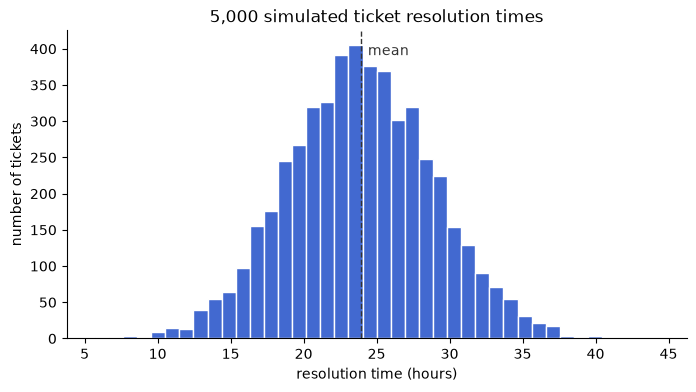

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

rng = np.random.default_rng(7)
times = rng.normal(loc=24, scale=5, size=5000)

print(f"mean = {times.mean():.2f} hours")
print(f"std  = {times.std():.2f} hours")

Path("plots").mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(times, bins=40, color="#4269d0", edgecolor="white")
ax.axvline(times.mean(), color="#333333", linestyle="--", linewidth=1)
ax.text(times.mean() + 0.5, ax.get_ylim()[1] * 0.92, "mean",
        color="#333333")
ax.set_xlabel("resolution time (hours)")
ax.set_ylabel("number of tickets")
ax.set_title("5,000 simulated ticket resolution times")
ax.spines[["top", "right"]].set_visible(False)
fig.savefig("plots/lesson-10-resolution-times.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 6. A classifier that admits uncertainty

Everything an AI system outputs is a bet, and good systems say how confident the bet is. Here is the simplest possible version: a keyword classifier that, instead of naming one category, reports a probability for **every** category — each category's share of the keyword matches found in the ticket.

Two tickets go in. The first is unambiguous — every matched word points at shipping. The second matches one billing word and one product word, an even split — and the honest output is 50/50, which is the classifier's way of saying "do not trust my top guess here." A real support system would auto-route the first ticket and send the second to a human. That confidence-threshold idea returns for real in the agent-guardrails lessons of Phase 8.

One caution to carry forward: the 100% on the first ticket only means "all the matched words point one way." It is the word tally's certainty, not a guarantee about the world — a ticket can use shipping words while actually needing a billing fix.

In [15]:
keywords = {
    "shipping": ["late", "delivery", "package", "tracking"],
    "billing": ["refund", "charged", "invoice", "payment"],
    "product": ["broken", "defective", "manual", "size"],
}

def category_probabilities(ticket):
    words = ticket.lower().split()
    counts = {cat: sum(word in words for word in kws)
              for cat, kws in keywords.items()}
    total = sum(counts.values())
    if total == 0:
        return {cat: 1 / len(counts) for cat in counts}
    return {cat: count / total for cat, count in counts.items()}

tickets = [
    "my package is late and tracking shows no delivery update",
    "i was charged for a broken item",
]

for ticket in tickets:
    probs = category_probabilities(ticket)
    best = max(probs, key=probs.get)
    pretty = ", ".join(f"{cat} {p:.2f}" for cat, p in probs.items())
    print(f"'{ticket}'")
    print(f"  probabilities: {pretty}")
    print(f"  best guess: {best} (confidence {probs[best]:.0%})")
    print()

'my package is late and tracking shows no delivery update'
  probabilities: shipping 1.00, billing 0.00, product 0.00
  best guess: shipping (confidence 100%)

'i was charged for a broken item'
  probabilities: shipping 0.00, billing 0.50, product 0.50
  best guess: billing (confidence 50%)



## What to remember

A probability is a fraction; evidence updates it; small samples wobble and big ones settle; a mean without its spread can lie; the histogram shows the whole shape; and a good model reports *how sure it is*, not just an answer. Phase 2's real classifiers output exactly these per-category probabilities — learned from data instead of counted from keywords.